In [1]:
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
import torch
import transformers
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoModel
from Bio import SeqIO
from Bio.SeqIO import FastaIO
import scipy.stats as stats
import torch.nn.functional as F
from tqdm import tqdm
import gc

In [2]:
def get_fasta_ids(fasta_path):
    """
    快速从FASTA文件中提取ID列表，保持顺序与文件一致。
    """
    ids = []
    with open(fasta_path, 'r') as f:
        for line in f:
            if line.startswith('>'):
                # 去除 '>' 和末尾换行符，提取纯ID
                # 假设header格式为 ">GeneID", 根据实际情况可能需要 split
                ids.append(line.strip()[1:]) 
    return ids

def filter_syntenic_rbh(species_name, base_dir, save_output=True):
    """
    执行双向最佳匹配 (RBH) 过滤。
    
    参数:
        species_name: 物种名称，如 'mouse', 'mouse' (用于构建文件名)
        base_dir: 数据所在的根目录，例如 '/.../batch_embedding/mouse/'
        save_output: 是否保存过滤后的 .pt 和 .csv 文件
    
    返回:
        filtered_human_emb: 过滤后的 Human Tensor
        filtered_other_emb: 过滤后的 Other Species Tensor
        df_rbh: 过滤后的详细 DataFrame
    """
    
    # 1. 定义文件路径 (根据你的截图结构)
    # 注意：这里假设文件名格式是固定的，如果大小写不同请调整
    # Human 文件
    h_emb_path = os.path.join(base_dir, f"HM_human_syntenic_non_homologous_emb.pt")
    h_fa_path = os.path.join(base_dir, f"HM_human_syntenic_non_homologous.fa")
    
    # Other Species 文件 (首字母大写处理，如 Mouse)
    sp_cap = species_name.capitalize() # mouse -> Mouse
    o_emb_path = os.path.join(base_dir, f"{sp_cap}_syntenic_non_homologous_emb.pt")
    o_fa_path = os.path.join(base_dir, f"{sp_cap}_syntenic_non_homologous.fa")

    print(f"正在处理物种: {species_name}")
    print(f"加载 Human 文件: {os.path.basename(h_emb_path)}")
    print(f"加载 {sp_cap} 文件: {os.path.basename(o_emb_path)}")

    # 2. 加载数据
    # 加载 Embedding
    h_emb = torch.load(h_emb_path, map_location='cpu')
    o_emb = torch.load(o_emb_path, map_location='cpu')
    
    # 加载 IDs
    h_ids = get_fasta_ids(h_fa_path)
    o_ids = get_fasta_ids(o_fa_path)
    
    # 检查对齐情况
    assert len(h_emb) == len(o_emb) == len(h_ids) == len(o_ids), \
        f"数据长度不一致! Emb: {len(h_emb)}, IDs: {len(h_ids)}"
    
    print(f"原始共线对数量: {len(h_ids)}")

    # 3. 计算余弦相似度 (为了保证精确对应，建议现场重新计算一遍，速度很快)
    # 假设 Orthrus 输出未归一化，先做归一化再点积 = 余弦相似度
    print("计算余弦相似度...")
    h_emb_norm = F.normalize(h_emb, p=2, dim=1)
    o_emb_norm = F.normalize(o_emb, p=2, dim=1)
    # 对应元素点积 (pair-wise cosine similarity)
    similarities = (h_emb_norm * o_emb_norm).sum(dim=1)
    
    # 4. 构建 DataFrame 用于筛选
    df = pd.DataFrame({
        'human_id': h_ids,
        'other_id': o_ids,
        'sim': similarities.numpy(),
        'original_idx': range(len(h_ids)) # 记录原始索引以便提取 Tensor
    })

    # 5. 执行双向最佳匹配 (RBH)
    print("执行 RBH 过滤...")
    
    # Step A: Human -> Other (对每个 Human 基因，选相似度最高的 Other 基因)
    # idxmax保留第一次出现的最大值索引
    idx_h_best = df.groupby('human_id')['sim'].idxmax()
    df_forward = df.loc[idx_h_best]
    
    # Step B: Other -> Human (在 Step A 的基础上，对每个 Other 基因，选相似度最高的 Human 基因)
    idx_rbh = df_forward.groupby('other_id')['sim'].idxmax()
    df_rbh = df_forward.loc[idx_rbh]
    
    print(f"过滤后剩余对数量: {len(df_rbh)} (过滤率: {1 - len(df_rbh)/len(df):.2%})")

    # 6. 提取过滤后的 Tensor
    valid_indices = torch.tensor(df_rbh['original_idx'].values, dtype=torch.long)
    
    filtered_h_emb = h_emb[valid_indices]
    filtered_o_emb = o_emb[valid_indices]

    # 7. 保存结果 (可选)
    if save_output:
        out_h_name = f"RBH_filtered_Human_{species_name}_emb.pt"
        out_o_name = f"RBH_filtered_{sp_cap}_emb.pt"
        out_csv_name = f"RBH_filtered_{species_name}_metadata.csv"
        
        torch.save(filtered_h_emb, os.path.join(base_dir, out_h_name))
        torch.save(filtered_o_emb, os.path.join(base_dir, out_o_name))
        df_rbh.drop(columns=['original_idx']).to_csv(os.path.join(base_dir, out_csv_name), index=False)
        
        print(f"结果已保存至: {base_dir}")
        print(f"  - {out_h_name}")
        print(f"  - {out_o_name}")
        print(f"  - {out_csv_name}")

    return filtered_h_emb, filtered_o_emb, df_rbh

# ================= 使用示例 =================
if __name__ == "__main__":
    # 根据你的截图修改路径
    # 假设脚本就在 batch_embedding 目录下运行，或者你需要指定绝对路径
    target_dir = r"/root/autodl-tmp/Orthrus/notebooks/batch_embedding/mouse/" 
    # 注意：请将上面的路径替换为你截图中的实际完整路径
    
    # 运行函数
    # 这里的 'mouse' 对应你文件夹名称和文件名中的前缀
    h_emb, c_emb, df = filter_syntenic_rbh('mouse', target_dir)
    
    # 检查一下 tensor 形状
    print("\nTensor Shapes:")
    print("Human:", h_emb.shape)
    print("Mouse:  ", c_emb.shape)

正在处理物种: mouse
加载 Human 文件: HM_human_syntenic_non_homologous_emb.pt
加载 Mouse 文件: Mouse_syntenic_non_homologous_emb.pt
原始共线对数量: 17653
计算余弦相似度...
执行 RBH 过滤...
过滤后剩余对数量: 4256 (过滤率: 75.89%)
结果已保存至: /root/autodl-tmp/Orthrus/notebooks/batch_embedding/mouse/
  - RBH_filtered_Human_mouse_emb.pt
  - RBH_filtered_Mouse_emb.pt
  - RBH_filtered_mouse_metadata.csv

Tensor Shapes:
Human: torch.Size([4256, 512])
Mouse:   torch.Size([4256, 512])


In [3]:
F.cosine_similarity(h_emb, c_emb)

tensor([0.8815, 0.9329, 0.9594,  ..., 0.9484, 0.9229, 0.9609])

In [4]:
human_homology_emb = torch.load("/root/autodl-tmp/Orthrus/notebooks/batch_embedding/mouse/HM_human_homo_emb.pt")
mouse_homology_emb = torch.load("/root/autodl-tmp/Orthrus/notebooks/batch_embedding/mouse/Mouse_homo_emb.pt")
human_syntenic_non_homo_emb = torch.load("/root/autodl-tmp/Orthrus/notebooks/batch_embedding/mouse/RBH_filtered_Human_mouse_emb.pt") 
mouse_syntenic_non_homo_emb = torch.load("/root/autodl-tmp/Orthrus/notebooks/batch_embedding/mouse/RBH_filtered_Mouse_emb.pt")

In [5]:
homology_cosines = F.cosine_similarity(human_homology_emb, mouse_homology_emb)
syntenic_cosines = F.cosine_similarity(human_syntenic_non_homo_emb, mouse_syntenic_non_homo_emb)

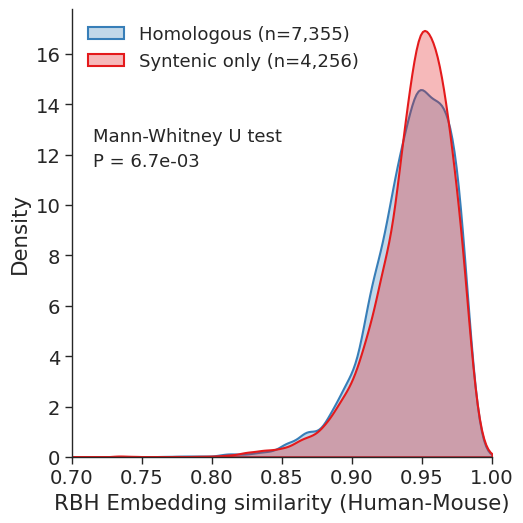

In [6]:
# 1. 数据准备
to_np = lambda x: x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.array(x)
d_h, d_s = to_np(homology_cosines), to_np(syntenic_cosines)

# 2. 统计检验 (保留两位有效数字的科学计数法)
_, p_val = stats.mannwhitneyu(d_h, d_s)
p_str = f"{p_val:.1e}"

# 3. 绘图设置 (去除粗体，仅画KDE)
sns.set_theme(style="ticks", context="paper", font_scale=1.6)
plt.figure(figsize=(5.5, 5.5))

# 绘制密度填充图 (fill=True, alpha控制透明度)
sns.kdeplot(d_h, fill=True, color="#377eb8", alpha=0.3, linewidth=1.5,
            label=f"Homologous (n={len(d_h):,})", clip=(0.7, 1.0))
sns.kdeplot(d_s, fill=True, color="#e41a1c", alpha=0.3, linewidth=1.5,
            label=f"Syntenic only (n={len(d_s):,})", clip=(0.7, 1.0))

# 4. 标注与修饰
ax = plt.gca()
ax.text(0.05, 0.65, f"Mann-Whitney U test\nP = {p_str}",
        transform=ax.transAxes, fontsize=13, linespacing=1.5)

plt.xlabel("RBH Embedding similarity (Human-Mouse)")
plt.ylabel("Density")
plt.xlim(0.7, 1.0)
plt.legend(loc='upper left', frameon=False, fontsize=13)
sns.despine()

plt.tight_layout()
plt.savefig('RBH_Embedding_similarity_Human_Mouse.pdf', bbox_inches='tight', dpi=300)
plt.savefig('RBH_Embedding_similarity_Human_Mouse.png', bbox_inches='tight', dpi=300)
plt.show()

# 检验

In [7]:
import pandas as pd
import os

def verify_datasets(base_dir, species_name, df_rbh):
    """
    参数:
        base_dir: 文件夹路径
        species_name: 物种名 (如 'mouse')
        df_rbh: 上一步生成的经过过滤的 DataFrame (包含 human_id, other_id)
    """
    print(f"--- 开始验证 {species_name} 数据集的纯净性 ---")
    
    # ==========================================
    # 1. 读取同源 (Homologous) ID 列表
    # ==========================================
    # 同源文件名构建
    sp_cap = species_name.capitalize()
    homo_h_fa = os.path.join(base_dir, "HM_human_homo.fa")
    homo_o_fa = os.path.join(base_dir, f"{sp_cap}_homo.fa")
    
    # 提取 ID (复用之前的 get_fasta_ids 函数)
    def get_ids(path):
        with open(path, 'r') as f:
            return [line.strip()[1:] for line in f if line.startswith('>')]

    homo_h_ids = get_ids(homo_h_fa)
    homo_o_ids = get_ids(homo_o_fa)
    
    # 构建同源对集合 (Set of Tuples)
    # 注意：同源文件通常是一一对应的，第i行对应第i行
    homo_pairs = set(zip(homo_h_ids, homo_o_ids))
    print(f"同源对 (Homologous) 总数: {len(homo_pairs)}")

    # ==========================================
    # 2. 读取原始共线不同源 (Raw Syntenic) ID 列表
    # ==========================================
    syn_h_fa = os.path.join(base_dir, "HM_human_syntenic_non_homologous.fa")
    syn_o_fa = os.path.join(base_dir, f"{sp_cap}_syntenic_non_homologous.fa")
    
    syn_h_ids = get_ids(syn_h_fa)
    syn_o_ids = get_ids(syn_o_fa)
    
    # 构建原始共线对集合
    raw_syntenic_pairs = set(zip(syn_h_ids, syn_o_ids))
    print(f"原始共线不同源 (Raw Syntenic) 总数: {len(raw_syntenic_pairs)}")

    # ==========================================
    # 3. 准备过滤后 (RBH) 的对集合
    # ==========================================
    # 确保去除可能存在的空格
    df_rbh['human_id'] = df_rbh['human_id'].astype(str).str.strip()
    df_rbh['other_id'] = df_rbh['other_id'].astype(str).str.strip()
    
    rbh_pairs = set(zip(df_rbh['human_id'], df_rbh['other_id']))
    print(f"RBH 过滤后数据集总数: {len(rbh_pairs)}")

    # ==========================================
    # 4. 执行检验 (The Tests)
    # ==========================================
    
    # 检验 A: 子集检验
    # 判断 RBH 是否完全属于 原始共线数据
    is_subset = rbh_pairs.issubset(raw_syntenic_pairs)
    
    # 检验 B: 互斥检验 (最重要!)
    # 判断 RBH 是否与 同源数据 有交集
    intersection = rbh_pairs.intersection(homo_pairs)
    is_clean = len(intersection) == 0
    
    print("\n--- 验证结果 ---")
    
    if is_subset:
        print("✅ 通过检验 A: 过滤后的数据完全是原始共线不同源数据的子集。")
    else:
        print("❌ 未通过检验 A: 警告！过滤后的数据包含原始列表中不存在的配对！(请检查索引逻辑)")
        # 打印出多余的
        diff = rbh_pairs - raw_syntenic_pairs
        print(f"   异常样本示例: {list(diff)[:3]}")

    if is_clean:
        print("✅ 通过检验 B: 过滤后的数据与同源数据完全无重叠（互斥）。")
        print("   结论: 负样本纯净，可以安全用于二分类训练。")
    else:
        print(f"❌ 未通过检验 B: 警告！发现 {len(intersection)} 对数据同时出现在同源列表中！")
        print("   这意味着原始分类可能有误，或者同源/共线表有重叠。")
        print(f"   重叠样本示例: {list(intersection)[:3]}")
        
    return is_subset and is_clean

# ================= 运行调用 =================
# 假设 base_dir 和 df_rbh 已经在上一步代码中定义好了
verify_datasets(target_dir, 'mouse', df)

--- 开始验证 zebrafish 数据集的纯净性 ---
同源对 (Homologous) 总数: 623
原始共线不同源 (Raw Syntenic) 总数: 108294
RBH 过滤后数据集总数: 4172

--- 验证结果 ---
✅ 通过检验 A: 过滤后的数据完全是原始共线不同源数据的子集。
✅ 通过检验 B: 过滤后的数据与同源数据完全无重叠（互斥）。
   结论: 负样本纯净，可以安全用于二分类训练。


True